In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from pandas import DataFrame
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from tqdm import tqdm

In [3]:
# Configure device with cuda

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device.type}")

Using device: cuda


In [4]:
def seed_everything(seed=42):
	np.random.seed(seed)
	torch.manual_seed(seed)
	if torch.cuda.is_available():
		torch.cuda.manual_seed_all(seed)
seed_everything()

In [5]:
# Load the Bike Sharing dataset
data_day: DataFrame = pd.read_csv("../data/bike+sharing+dataset/day.csv", parse_dates=["dteday"])
data_hour: DataFrame = pd.read_csv("../data/bike+sharing+dataset/hour.csv", parse_dates=["dteday"])
# Prefer data_hour for more granular analysis

In [6]:
data_hour.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [7]:
data_hour.info()

<class 'pandas.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     17379 non-null  int64         
 1   dteday      17379 non-null  datetime64[us]
 2   season      17379 non-null  int64         
 3   yr          17379 non-null  int64         
 4   mnth        17379 non-null  int64         
 5   hr          17379 non-null  int64         
 6   holiday     17379 non-null  int64         
 7   weekday     17379 non-null  int64         
 8   workingday  17379 non-null  int64         
 9   weathersit  17379 non-null  int64         
 10  temp        17379 non-null  float64       
 11  atemp       17379 non-null  float64       
 12  hum         17379 non-null  float64       
 13  windspeed   17379 non-null  float64       
 14  casual      17379 non-null  int64         
 15  registered  17379 non-null  int64         
 16  cnt         17379 non-null  int64

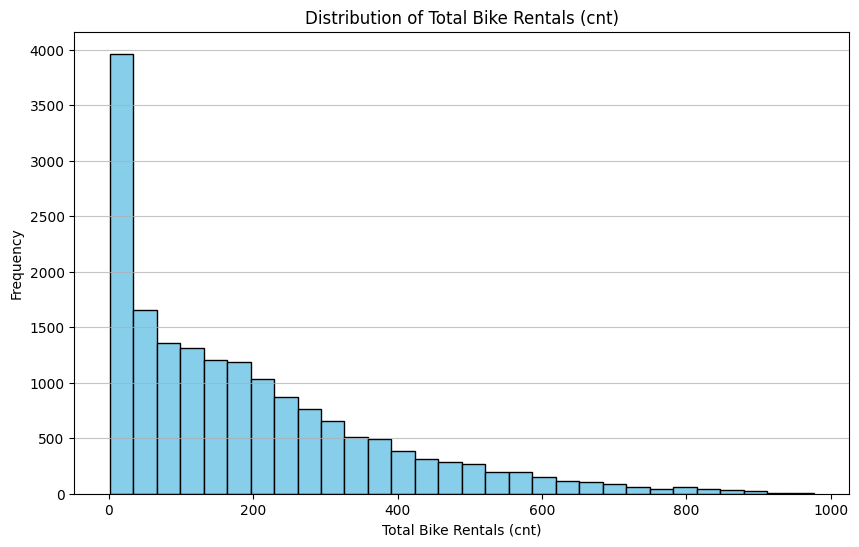

In [8]:
# Plot the distribution of the target variable 'cnt' (total bike rentals)
plt.figure(figsize=(10, 6))
plt.hist(data_hour["cnt"], bins=30, color="skyblue", edgecolor="black")
plt.title("Distribution of Total Bike Rentals (cnt)")
plt.xlabel("Total Bike Rentals (cnt)")
plt.ylabel("Frequency")
plt.grid(axis="y", alpha=0.75)
plt.show()

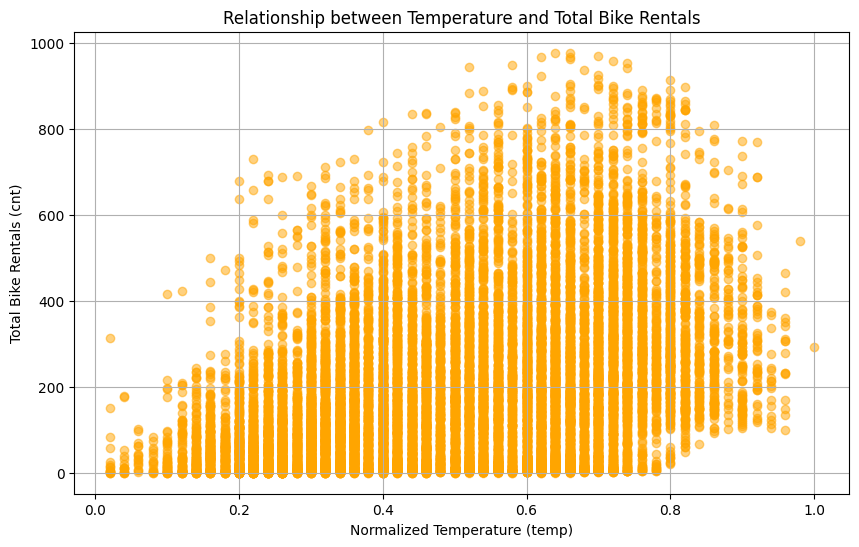

In [9]:
# Plot the relationship between 'temp' (normalized temperature) and 'cnt' (total bike rentals)
plt.figure(figsize=(10, 6))
plt.scatter(data_hour["temp"], data_hour["cnt"], alpha=0.5, color="orange")
plt.title("Relationship between Temperature and Total Bike Rentals")
plt.xlabel("Normalized Temperature (temp)")
plt.ylabel("Total Bike Rentals (cnt)")
plt.grid()

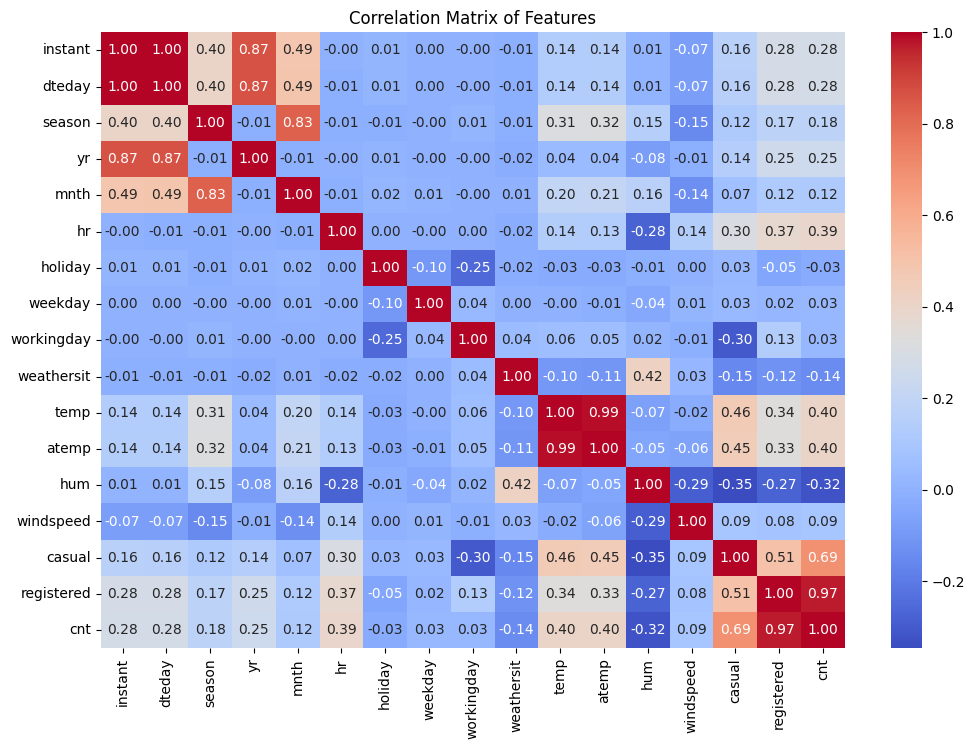

In [10]:
# Plot matrix of features to visualize relationships

plt.figure(figsize=(12, 8))
sns.heatmap(data_hour.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Features")
plt.show()

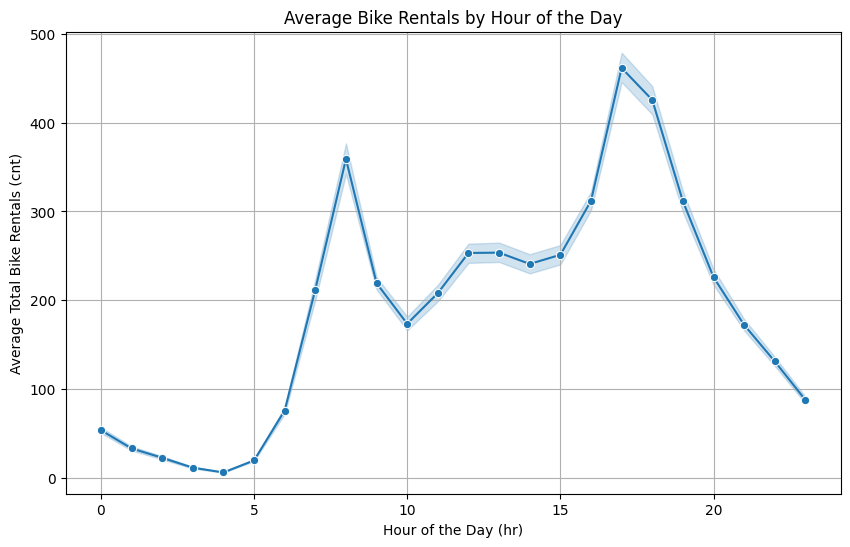

In [11]:
# Plot the average bike rentals by hour of the day
plt.figure(figsize=(10, 6))
sns.lineplot(x="hr", y="cnt", data=data_hour, marker="o")
plt.title("Average Bike Rentals by Hour of the Day")
plt.xlabel("Hour of the Day (hr)")
plt.ylabel("Average Total Bike Rentals (cnt)")
plt.grid()

In [12]:
# Data Preparation for PyTorch
features_to_drop = ['instant', 'dteday', 'casual', 'registered', 'cnt']
X = data_hour.drop(columns=features_to_drop).values
y = data_hour['cnt'].values.reshape(-1, 1)  # Reshape for PyTorch

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled = scaler_y.transform(y_test)

X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train_scaled, dtype=torch.float32)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_t = torch.tensor(y_test_scaled, dtype=torch.float32)


class BikeDataset(Dataset):
    def __init__(self, X_tensor: torch.Tensor, y_tensor: torch.Tensor) -> None:
        self.X = X_tensor
        self.y = y_tensor

    def __len__(self) -> int:
        return len(self.X)

    def __getitem__(self, idx: int) -> tuple[torch.Tensor, torch.Tensor]:
        return self.X[idx], self.y[idx]

batch_size = 64
train_loader = DataLoader(BikeDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True)
test_loader = DataLoader(BikeDataset(X_test_t, y_test_t), batch_size=batch_size, shuffle=False)

In [ ]:
# Define a simple linear regression model
class LinearRegressionModel(torch.nn.Module):
	def __init__(self, input_dim):
		super(LinearRegressionModel, self).__init__()
		self.linear = torch.nn.Linear(input_dim, 1)

	def forward(self, x: torch.Tensor) -> torch.Tensor:
		return self.linear(x)

# Initialize the model, define the loss function and the optimizer
input_dim = X_train.shape[1]
model = LinearRegressionModel(input_dim).to(device)
criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# Train the model
epochs = 1000
history = {'train_loss': [], 'val_loss': []}

# Training Loop with tqdm
pbar = tqdm(range(epochs), desc="Training", unit="epoch")
for epoch in pbar:
    # Training Phase
    model.train()
    train_loss_accum = 0.0
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)

        predictions = model(batch_X)
        loss = criterion(predictions, batch_y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss_accum += loss.item()

    avg_train_loss = train_loss_accum / len(train_loader)
    history['train_loss'].append(avg_train_loss)

    # Validation Phase
    model.eval()
    val_loss_accum = 0.0
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            preds = model(batch_X)
            val_loss = criterion(preds, batch_y)
            val_loss_accum += val_loss.item()

    avg_val_loss = val_loss_accum / len(test_loader)
    history['val_loss'].append(avg_val_loss)

    # Update Progress Bar
    pbar.set_postfix({'Train Loss': f"{avg_train_loss:.4f}", 'Val Loss': f"{avg_val_loss:.4f}"})

Training:  35%|███▌      | 353/1000 [02:35<04:38,  2.33epoch/s, Train Loss=0.6177, Val Loss=0.5893]

In [ ]:
# Evaluate the model on the test set
model.eval()
test_loss = 0.0
with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        preds = model(batch_X)
        loss = criterion(preds, batch_y)
        test_loss += loss.item()

print(f"Test MSE Loss: {test_loss / len(test_loader):.4f}")

In [ ]:
# Plotting the Training Curves
plt.figure(figsize=(10, 6))
plt.plot(history['train_loss'], label='Train Loss', color='#3b82f6', linewidth=2)
plt.plot(history['val_loss'], label='Validation Loss', color='#ef4444', linewidth=2, linestyle='--')
plt.title('Training and Validation Loss', fontsize=14, pad=15)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('MSE Loss', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=12)
plt.show()